In [66]:
import random
import shutil
from tqdm import tqdm
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json



In [21]:
import os
print(os.listdir('/data/project/MSA8395/mapillary_traffic_sign_dataset'))

['donwload_urls.txt', 'images', 'mtsd_v2_partially_annotated', 'mtsd_v2_fully_annotated', 'LICENSE.txt', '__trash']


In [22]:
import os

anno_dir = '/data/project/MSA8395/mapillary_traffic_sign_dataset/mtsd_v2_fully_annotated'
print(os.listdir(anno_dir))


['annotations', 'splits', 'README.md', 'requirements.txt', 'visualize_example.py', '.ipynb_checkpoints']


In [23]:
#Defines dataset paths, sampling parameters, and train/validation/test split ratios for curating a focused subset of traffic sign images.

In [25]:
#Loads all JSON annotation files from the dataset directory and collects image-level object information into a list for further processing.

In [ ]:
import os

root1 = "/data/project/MSA8395/mapillary_traffic_sign_dataset/mtsd_v2_fully_annotated/annotations"
root2 = "/data/project/MSA8395/mapillary_traffic_sign_dataset/mtsd_v2_partially_annotated/annotations"

print("Fully annotated:", len(os.listdir(root1)) if os.path.exists(root1) else "Not found")
print("Partially annotated:", len(os.listdir(root2)) if os.path.exists(root2) else "Not found")

files = os.listdir(root2)[:10]
print("Example files:", files)


In [51]:
# CONFIG 
class Args:
    images_dir = '/data/project/MSA8395/mapillary_traffic_sign_dataset/images'
    annotations_dir = '/data/project/MSA8395/mapillary_traffic_sign_dataset/mtsd_v2_fully_annotated/annotations'
    out_dir = '/home/knaidu1/Untitled Folder/BuildingGenerativeAIBusinessSolutions/Homework2/data/curated_dataset'
    num_classes = 5
    per_class = 100
    seed = 42
    train_frac = 0.7
    val_frac = 0.15
    test_frac = 0.15
    use_symlink = False

args = Args()

In [50]:
# 1. LOAD ANNOTATIONS 
print("Loading all annotation files...")
annotations = []
for file in tqdm(os.listdir(args.annotations_dir)):
    if file.endswith(".json"):
        with open(os.path.join(args.annotations_dir, file), "r") as f:
            data = json.load(f)
            if "objects" in data:
                annotations.append({"file": file, **data})
print(f"Loaded {len(annotations)} annotation files.")

# 2. CATEGORY FREQUENCY
category_counts = Counter()
for ann in annotations:
    for obj in ann["objects"]:
        if "label" in obj and obj["label"] != "unknown":
            category_counts[obj["label"]] += 1
top_classes = [cls for cls, _ in category_counts.most_common(args.num_classes)]
print(f"Top {args.num_classes} classes: {top_classes}")

Loading all annotation files...


100%|██████████| 41909/41909 [00:28<00:00, 1487.06it/s]


Loaded 41909 annotation files.
Top 5 classes: ['other-sign', 'regulatory--yield--g1', 'information--pedestrians-crossing--g1', 'regulatory--no-entry--g1', 'complementary--chevron-left--g1']


In [ ]:
#Visualization

In [48]:
#3. SAMPLE IMAGES FOR EACH CLASS 
random.seed(args.seed)
selected_images = {}
for cls in top_classes:
    imgs = []
    for ann in annotations:
        labels = [obj["label"] for obj in ann["objects"]]
        if cls in labels:
            img_name = os.path.splitext(ann["file"])[0] + ".jpg"
            imgs.append(img_name)
    imgs = list(set(imgs))
    sampled = random.sample(imgs, min(args.per_class, len(imgs)))
    selected_images[cls] = sampled
    print(f"{cls}: {len(sampled)} images")

other-sign: 100 images
regulatory--yield--g1: 100 images
information--pedestrians-crossing--g1: 100 images
regulatory--no-entry--g1: 100 images
complementary--chevron-left--g1: 100 images


In [49]:
# 4. COMBINE UNIQUE IMAGE LIST 
all_selected = list(set(sum(selected_images.values(), [])))
print(f"Total unique selected images: {len(all_selected)}")

# 5. SPLIT INTO TRAIN/VAL/TEST
random.shuffle(all_selected)
n_train = int(len(all_selected) * args.train_frac)
n_val = int(len(all_selected) * args.val_frac)
train_imgs = all_selected[:n_train]
val_imgs = all_selected[n_train:n_train + n_val]
test_imgs = all_selected[n_train + n_val:]

splits = {"train": train_imgs, "val": val_imgs, "test": test_imgs}
print({k: len(v) for k, v in splits.items()})

#  6. COPY OR SYMLINK IMAGES
for split_name, img_list in splits.items():
    split_dir = os.path.join(args.out_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    for img_name in tqdm(img_list, desc=f"Copying {split_name} images"):
        src = os.path.join(args.images_dir, img_name)
        dst = os.path.join(split_dir, img_name)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        if os.path.exists(src) and not os.path.exists(dst):
            if args.use_symlink:
                os.symlink(src, dst)
            else:
                shutil.copy(src, dst)

print("Dataset curation complete!")
print(f"Output saved in {args.out_dir}")

#7. SAVE CLASS FREQUENCY 
summary_path = os.path.join(args.out_dir, "classsummary.json")
with open(summary_path, "w") as f:
    json.dump(dict(category_counts.most_common(args.num_classes)), f, indent=4)
print(f"Saved class frequency summary to {summary_path}")

Total unique selected images: 498
{'train': 348, 'val': 74, 'test': 76}


Copying test images: 100%|██████████| 76/76 [00:00<00:00, 3627.34it/s]

Dataset curation complete!
Output saved in /home/knaidu1/Untitled Folder/BuildingGenerativeAIBusinessSolutions/Homework2/data/curated_dataset
Saved class frequency summary to /home/knaidu1/Untitled Folder/BuildingGenerativeAIBusinessSolutions/Homework2/data/curated_dataset/classsummary.json


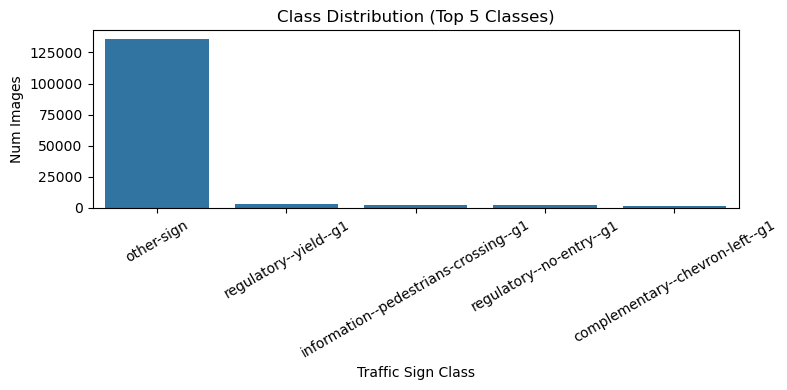

In [57]:
# Load prepared summary
with open("/home/knaidu1/Untitled Folder/BuildingGenerativeAIBusinessSolutions/Homework2/data/curated_dataset/classsummary.json", "r") as f:
    class_counts = json.load(f)

# Visualize class distribution
plt.figure(figsize=(8,4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution (Top 5 Classes)")
plt.ylabel("Num Images")
plt.xlabel("Traffic Sign Class")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


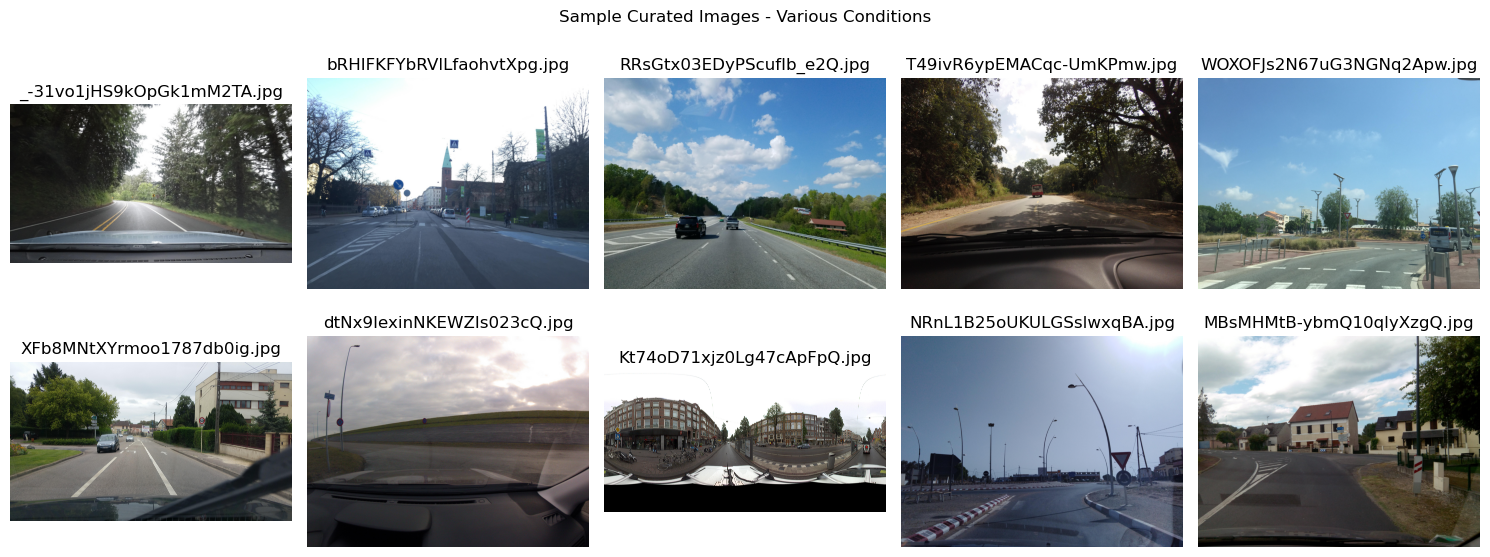

In [64]:
from PIL import Image

img_sample_dir = "./curated_dataset/train"   # Use train split for samples
sampled_imgs = random.sample(os.listdir(img_sample_dir), 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, img_name in zip(axes.flat, sampled_imgs):
    img = Image.open(os.path.join(img_sample_dir, img_name))
    ax.imshow(img)
    ax.set_title(img_name)
    ax.axis('off')
plt.suptitle("Sample Curated Images - Various Conditions")
plt.tight_layout()
plt.show()


In [65]:
# markdown cells in code cell
print("""
**Challenges observed:**
- High scale variation in traffic signs (very small to large signs in images).
- Many images contain multiple traffic signs, requiring multi-object detection logic.
- Significant background complexity, occlusion, and extreme variation in lighting/weather.
- Slight class imbalance if less than 100 images available for some class.
""")



**Challenges observed:**
- High scale variation in traffic signs (very small to large signs in images).
- Many images contain multiple traffic signs, requiring multi-object detection logic.
- Significant background complexity, occlusion, and extreme variation in lighting/weather.
- Slight class imbalance if less than 100 images available for some class.

